<a href="https://colab.research.google.com/github/MiguelGonzalez197/Proyectos-Deep-Learning/blob/Miguel-Gonzalez/Modelo_1_CNN_Braille.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔵 Reconocimiento de Caracteres Braille con CNN - CORTE 2
### Deep Learning — Clasificación de imágenes (A-Z en Braille)
**Dataset:** Braille Character Image Classification (Kaggle) — 26 clases, 100 imágenes/clase

Desarrollado por:

*   Miguel Angel Gonzalez Contreras
*   Andres Sebastian Gutierrez Ramirez
*   Oscar Javier Herrera Ereu


In [ ]:
# ============================================================
# BLOQUE 1: Instalación y configuración de Kaggle
# ============================================================
!pip install kaggle -q

import os
import json

# Configurar credenciales de Kaggle directamente
os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_credentials = {
    "username": "miguelgonzalez197",
    "key": "KGAT_5df565c2722f36419f5192c594c772ba"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Credenciales de Kaggle configuradas')

Credenciales de Kaggle configuradas


In [ ]:
# ============================================================
# BLOQUE 2: Descarga y extracción del dataset
# ============================================================
!kaggle datasets download -d mdismielhossenabir/braille-character-image-classification -p /content/data --unzip -q
print('Dataset descargado y extraído')

# Ver estructura del dataset
import os
base_path = '/content/data'

# Buscar la carpeta raíz que contiene las subcarpetas A-Z
for item in sorted(os.listdir(base_path)):
    item_path = os.path.join(base_path, item)
    if os.path.isdir(item_path):
        sub = os.listdir(item_path)
        if len(sub) > 0 and os.path.isdir(os.path.join(item_path, sub[0])):
            print(f'📁 Carpeta raíz detectada: {item}/')
            base_path = item_path
            break

print(f'\n Usando base_path: {base_path}')
for item in sorted(os.listdir(base_path)):
    item_path = os.path.join(base_path, item)
    if os.path.isdir(item_path):
        n_files = len(os.listdir(item_path))
        print(f'  📁 {item}/ → {n_files} imágenes')

Dataset URL: https://www.kaggle.com/datasets/mdismielhossenabir/braille-character-image-classification
License(s): MIT
Dataset descargado y extraído
📁 Carpeta raíz detectada: Braille Alphabet Image Dataset (A–Z)/

 Usando base_path: /content/data/Braille Alphabet Image Dataset (A–Z)
  📁 A/ → 100 imágenes
  📁 B/ → 100 imágenes
  📁 C/ → 100 imágenes
  📁 D/ → 100 imágenes
  📁 E/ → 100 imágenes
  📁 F/ → 100 imágenes
  📁 G/ → 100 imágenes
  📁 H/ → 100 imágenes
  📁 I/ → 100 imágenes
  📁 J/ → 100 imágenes
  📁 K/ → 100 imágenes
  📁 L/ → 100 imágenes
  📁 M/ → 100 imágenes
  📁 N/ → 100 imágenes
  📁 O/ → 100 imágenes
  📁 P/ → 100 imágenes
  📁 Q/ → 100 imágenes
  📁 R/ → 100 imágenes
  📁 S/ → 100 imágenes
  📁 T/ → 100 imágenes
  📁 U/ → 100 imágenes
  📁 V/ → 100 imágenes
  📁 W/ → 100 imágenes
  📁 X/ → 100 imágenes
  📁 Y/ → 100 imágenes
  📁 Z/ → 100 imágenes


In [ ]:
# ============================================================
# BLOQUE 3: Imports y librerías
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print(f'TensorFlow versión: {tf.__version__}')
print(f'GPU disponible: {tf.config.list_physical_devices("GPU")}')

TensorFlow versión: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# BLOQUE 4: Preparación del dataset con ImageDataGenerator
# ============================================================
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 42


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False
)


val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    base_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    color_mode='rgb'
)

val_generator = val_datagen.flow_from_directory(
    base_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    color_mode='rgb'
)

NUM_CLASSES = len(train_generator.class_indices)
CLASS_NAMES = list(train_generator.class_indices.keys())

print(f'\n Clases detectadas: {NUM_CLASSES}')
print(f'   Clases: {CLASS_NAMES}')
print(f'   Imágenes de entrenamiento: {train_generator.samples}')
print(f'   Imágenes de validación:    {val_generator.samples}')

Found 2080 images belonging to 26 classes.
Found 520 images belonging to 26 classes.

 Clases detectadas: 26
   Clases: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
   Imágenes de entrenamiento: 2080
   Imágenes de validación:    520


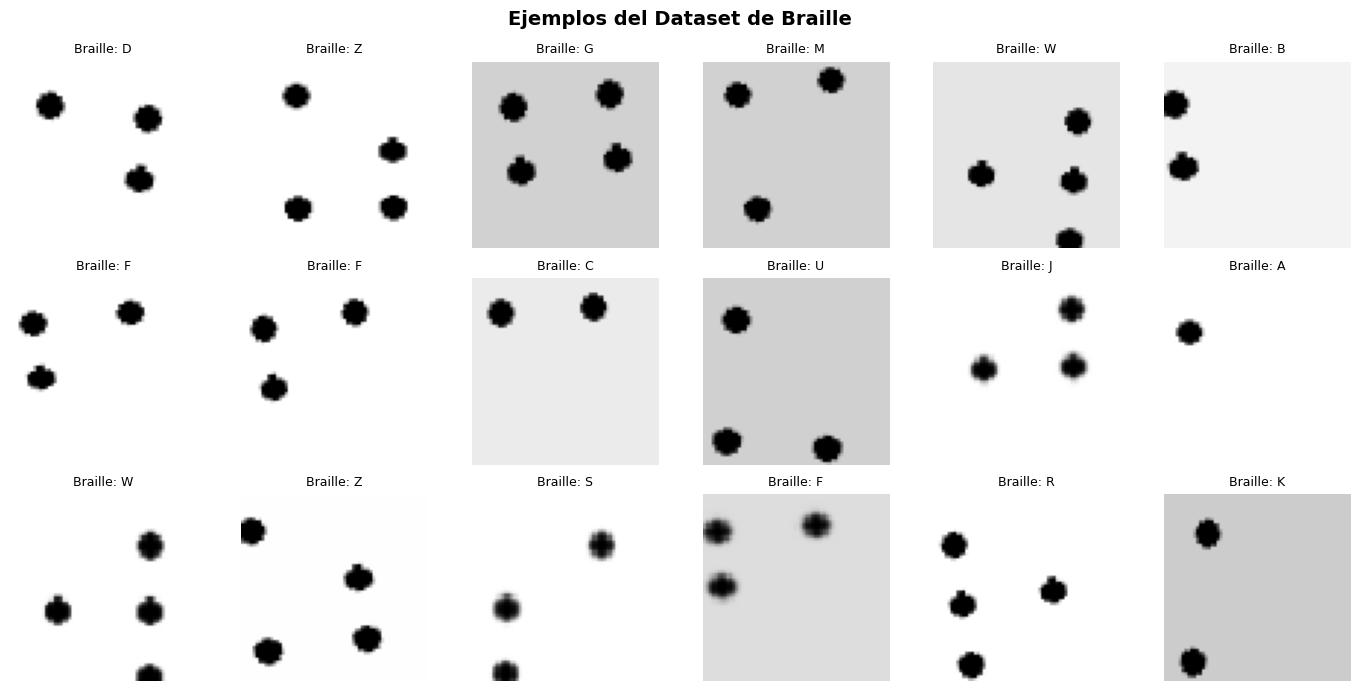

In [ ]:
# ============================================================
# BLOQUE 5: Visualización de ejemplos del dataset
# ============================================================
images, labels = next(train_generator)
label_indices = np.argmax(labels, axis=1)
label_names = [CLASS_NAMES[i] for i in label_indices]

fig, axes = plt.subplots(3, 6, figsize=(14, 7))
axes = axes.flatten()

for i in range(18):
    axes[i].imshow(images[i])
    axes[i].set_title(f'Braille: {label_names[i]}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Ejemplos del Dataset de Braille', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BLOQUE 6: Definición del modelo CNN (Baseline)
# ============================================================
def build_cnn(input_shape=(64, 64, 3), num_classes=26):
    model = models.Sequential([

        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),


        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),


        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),


        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn(input_shape=(64, 64, 3), num_classes=NUM_CLASSES)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 26)             │         6,682 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,245,434 (8.57 MB)

 Trainable params: 2,244,474 (8.56 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ============================================================
# BLOQUE 7: Entrenamiento del modelo
# ============================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

EPOCHS = 30

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('\n Entrenamiento completado')

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.6269 - loss: 1.3148 - val_accuracy: 0.0385 - val_loss: 8.0009 - learning_rate: 0.0010
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9202 - loss: 0.3313 - val_accuracy: 0.0385 - val_loss: 15.3161 - learning_rate: 0.0010
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9731 - loss: 0.1626 - val_accuracy: 0.0385 - val_loss: 25.1258 - learning_rate: 0.0010
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9851 - loss: 0.1038 - val_accuracy: 0.0385 - val_loss: 30.4769 - learning_rate: 0.0010
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.9880 - loss: 0.0752 - val_accuracy: 0.0385 - val_loss: 28.9968 - learning_rate: 0.0010
Epoch 6/30
64/65 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9953 - loss: 0.0569
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9928 - loss: 0.0594 - val

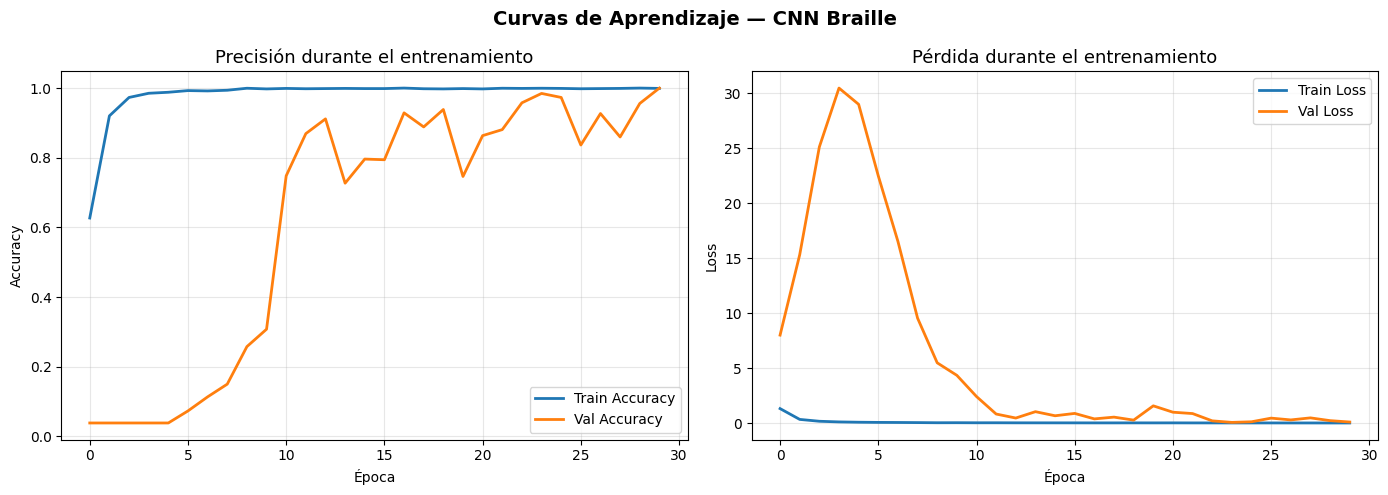

In [ ]:
# ============================================================
# BLOQUE 8: Curvas de aprendizaje
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Precisión durante el entrenamiento', fontsize=13)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perdida
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Pérdida durante el entrenamiento', fontsize=13)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — CNN Braille', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BLOQUE 9: Evaluación del modelo — Métricas generales
# ============================================================
val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)
print(f'{'='*45}')
print(f'  RESULTADOS FINALES EN VALIDACIÓN')
print(f'{'='*45}')
print(f'  Loss:     {val_loss:.4f}')
print(f'  Accuracy: {val_accuracy*100:.2f}%')
print(f'{'='*45}')

  RESULTADOS FINALES EN VALIDACIÓN
  Loss:     0.0607
  Accuracy: 98.46%


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Total muestras evaluadas: 520
Clases únicas en y_true: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
Clases únicas en y_pred: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]

 REPORTE DE CLASIFICACIÓN POR LETRA:
              precision    recall  f1-score   support

           A       0.74      1.00      0.85        20
           B       1.00

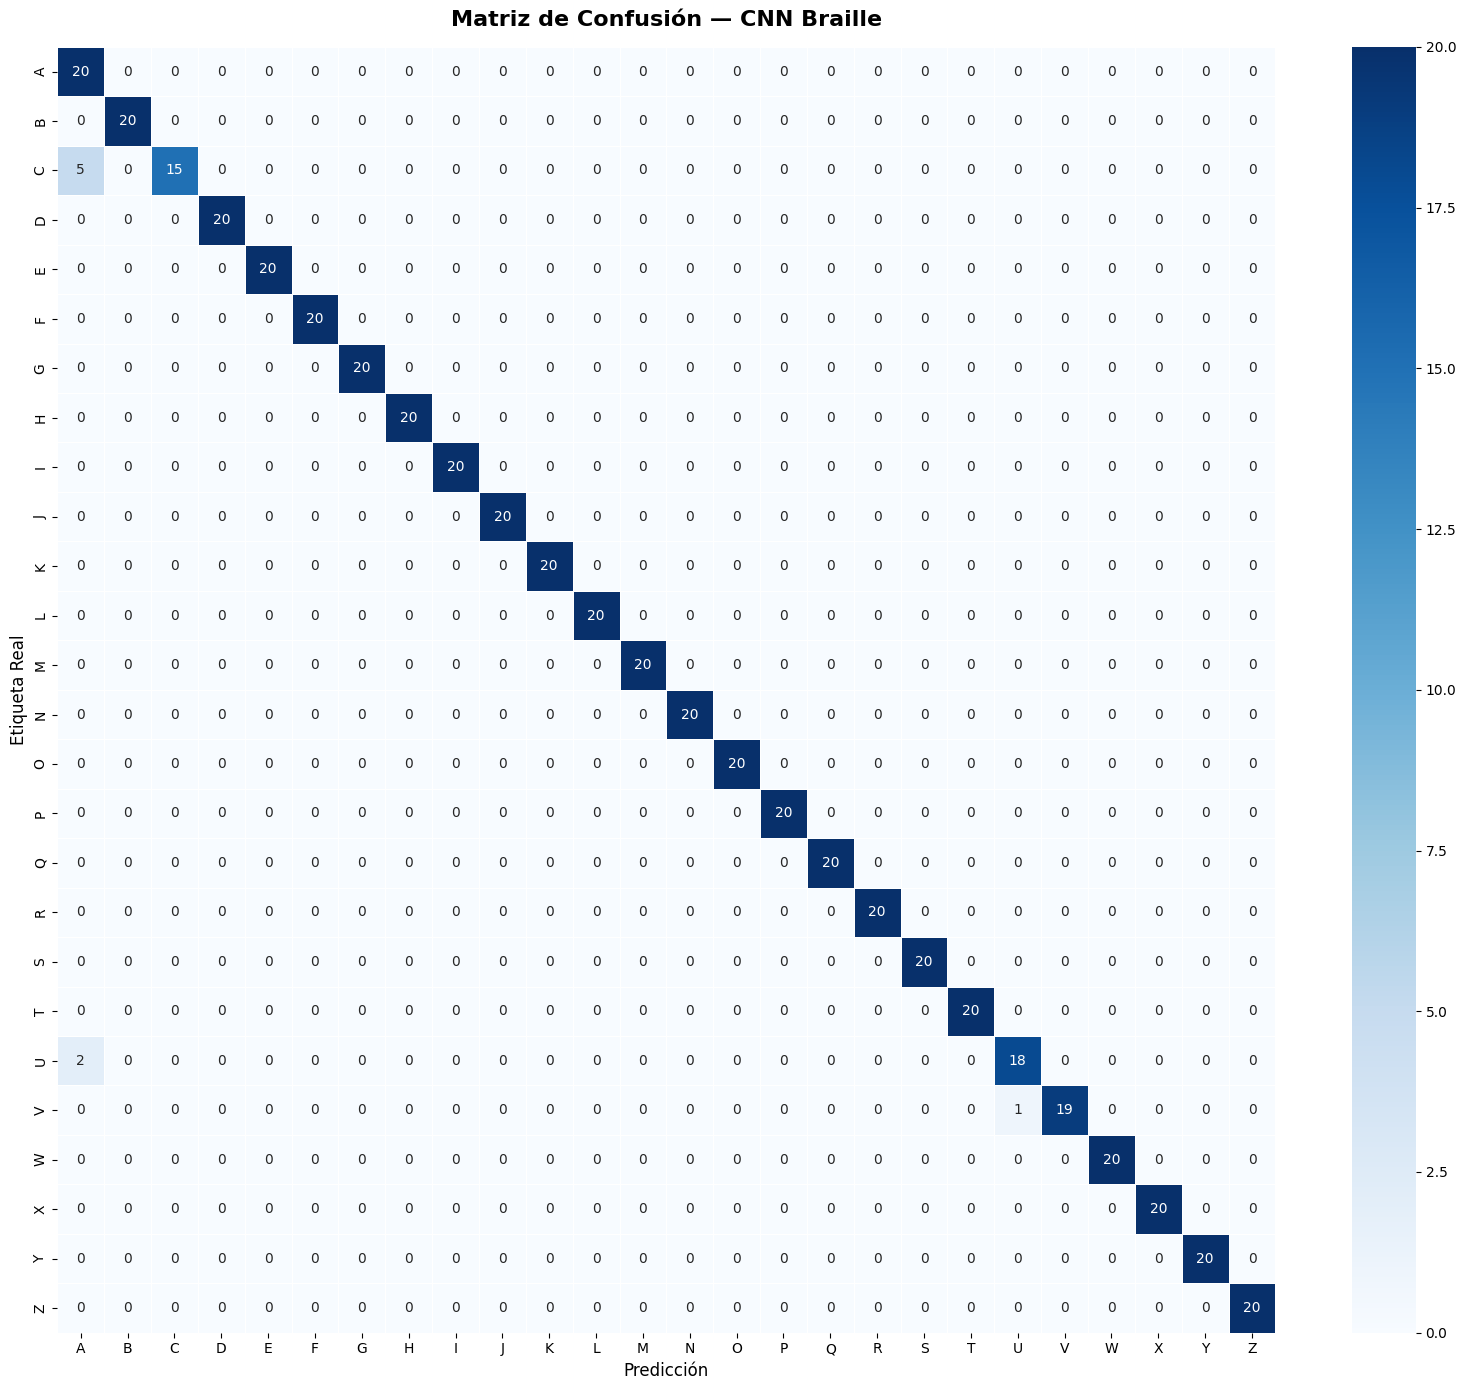

In [ ]:
# ============================================================
# BLOQUE 10: Reporte de clasificación y matriz de confusión
# ============================================================

val_generator.reset()

all_images = []
all_labels = []

steps = len(val_generator)
for i in range(steps):
    imgs, lbls = next(val_generator)
    all_images.append(imgs)
    all_labels.append(lbls)

X_val = np.concatenate(all_images, axis=0)
Y_val = np.concatenate(all_labels, axis=0)


y_pred_probs = model.predict(X_val, batch_size=32, verbose=1)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(Y_val, axis=1)

print(f'\nTotal muestras evaluadas: {len(y_true)}')
print(f'Clases únicas en y_true: {sorted(np.unique(y_true))}')
print(f'Clases únicas en y_pred: {sorted(np.unique(y_pred))}')

print('\n REPORTE DE CLASIFICACIÓN POR LETRA:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# --- Matriz de confusión ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    vmin=0
)
plt.title('Matriz de Confusión — CNN Braille', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.tight_layout()
plt.show()


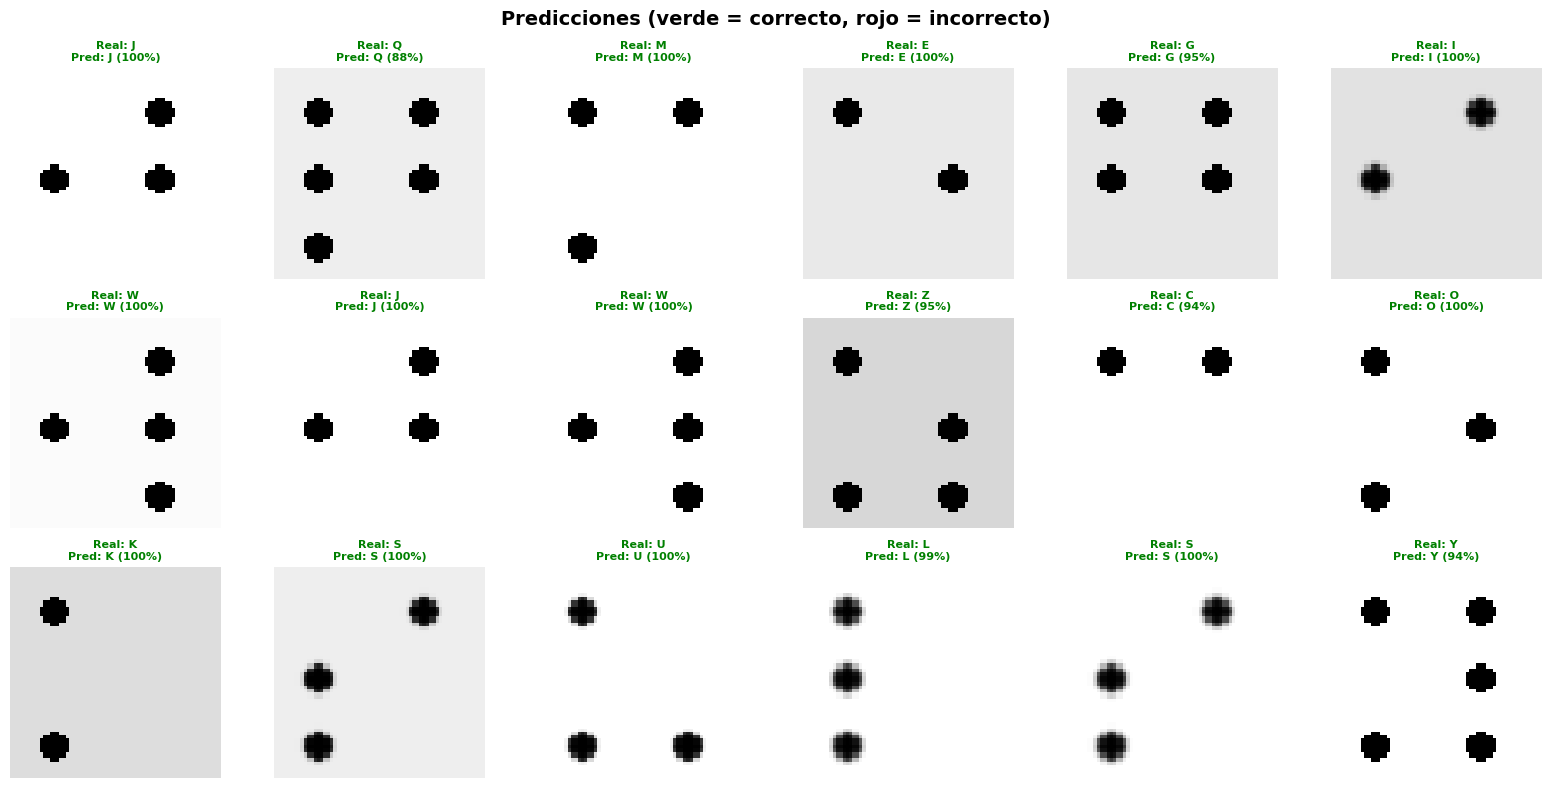

In [ ]:
# ============================================================
# BLOQUE 11: Prueba visual con predicciones individuales
# ============================================================
val_generator.reset()
images_test, labels_test = next(val_generator)
preds = model.predict(images_test, verbose=0)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
axes = axes.flatten()

for i in range(18):
    true_label = CLASS_NAMES[np.argmax(labels_test[i])]
    pred_label = CLASS_NAMES[np.argmax(preds[i])]
    confidence = np.max(preds[i]) * 100

    axes[i].imshow(images_test[i])
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f'Real: {true_label}\nPred: {pred_label} ({confidence:.0f}%)',
        fontsize=8, color=color, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle('Predicciones (verde = correcto, rojo = incorrecto)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BLOQUE 12: Guardar el modelo entrenado
# ============================================================
model.save('/content/cnn_braille_model.h5')
print(' Modelo guardado en /content/cnn_braille_model.h5')

# Descargar el modelo desde Colab
from google.colab import files
files.download('/content/cnn_braille_model.h5')

 Modelo guardado en /content/cnn_braille_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>